#### imports

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchmetrics

import helper_utils

helper_utils.set_seed(42)

In [2]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")

#### learning rate optimization on cifar-10

In [3]:
class SimpleCNN(nn.Module):

    def __init__(self):

        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [4]:
def evaluate_accuracy(model, val_loader, device):

    model.eval()
    total_correct = 0
    total_sample = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)

            _, predicted = outputs.max(1)
            total_correct += (predicted == labels).sum().item()
            total_sample += labels.size(0)

        accuracy = total_correct / total_sample
        return accuracy

In [5]:
def train_and_evaluate(learning_rate, device, n_epochs=10, batch_size=32):

    model = SimpleCNN().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_dataloader, val_dataloader = helper_utils.get_dataset_dataloaders(batch_size=batch_size)

    helper_utils.train_model(model=model, loss_fcn=loss_fn, optimizer=optimizer, train_dataloader=train_dataloader, device=device, n_epochs=n_epochs)

    accuracy = evaluate_accuracy(model, val_dataloader, device)

    print(f"Learning Rate: {learning_rate}, Accuracy: {accuracy:.4f}")
    return accuracy

In [6]:
learning_rates = [0.00001, 0.0001, 0.001, 0.01, 0.1] # low to high
accuracies = []

for lr in learning_rates:
    acc = train_and_evaluate(learning_rate=lr, device=device)
    accuracies.append(acc)

/Users/ramazanyildiz/PycharmProjects/pytorch/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
/Users/ramazanyildiz/PycharmProjects/pytorch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Training - Current Batch: 11:  17%|█▋        | 11/63 [00:00<00:00, 58.59it/s]

Epoch 5 - Train Loss: 2.2589



Training - Current Batch: 10:  16%|█▌        | 10/63 [00:00<00:00, 54.46it/s]

Epoch 10 - Train Loss: 2.1787



Training - Current Batch: 10:  16%|█▌        | 10/63 [00:00<00:00, 55.08it/s]

...

Epoch 15 - Train Loss: 2.3086



Training - Current Batch: 9:  14%|█▍        | 9/63 [00:00<00:01, 49.52it/s]

Epoch 20 - Train Loss: 2.3073



Training - Current Epoch: 25: 100%|██████████| 25/25 [00:36<00:00,  1.48s/it]

                                                                             

Epoch 25 - Train Loss: 2.3085
Training complete!

Learning Rate: 0.1, Accuracy: 0.1055


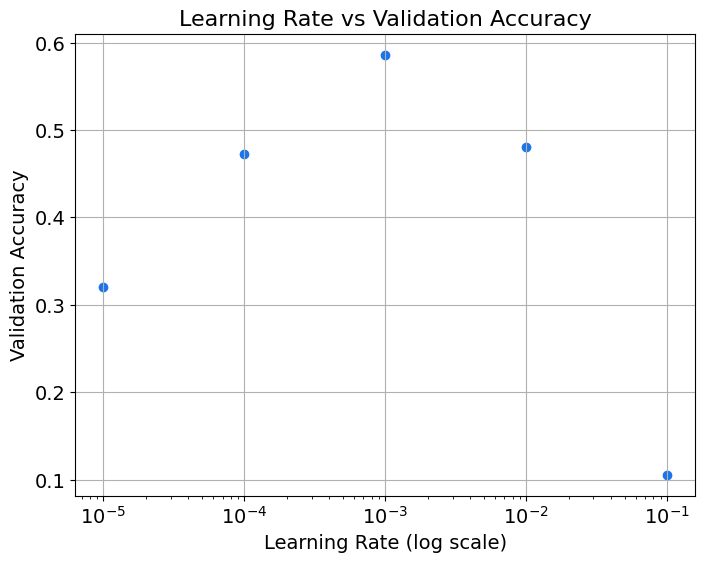

In [7]:
helper_utils.plot_results(learning_rates, accuracies)

#### implementing metrics in pytorch

In [9]:
def evaluate_metrics(model, val_loader, device, num_classes=10):

    model.eval()
    # initialize all the metrics
    accuracy_metric = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes, average="macro").to(device)

    precision_metric = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average="macro").to(device)

    recall_metric = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average="macro").to(device)

    f1_metric = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device)


    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)

            _, predicted = outputs.max(1)

            # update the metrics with the predictions and true labels for the current batch
            accuracy_metric.update(preds=predicted, target=labels)

            precision_metric.update(preds=predicted, target=labels)

            recall_metric.update(preds=predicted, target=labels)

            f1_metric.update(preds=predicted, target=labels)

        # compute the final metrics over the entire dataset
        accuracy = accuracy_metric.compute().item()
        precision = precision_metric.compute().item()
        recall = recall_metric.compute().item()
        f1_score = f1_metric.compute().item()

        return accuracy, precision, recall, f1_score

In [10]:
model = SimpleCNN().to(device)

train_dataloader, val_dataloader = helper_utils.get_dataset_dataloaders(batch_size=32)

accuracy, precision, recall, f1_score = evaluate_metrics(model, val_dataloader, device)

print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1_score:.4f}")

Accuracy: 0.1028, Precision: 0.0229, Recall: 0.1028, F1 Score: 0.0344
